# Pipeline ML — Ames Housing (Iowa, USA)

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

### Origen y contexto
- **Origen**: conjunto de datos de viviendas de **Ames, Iowa (EE.UU.)**, usado habitualmente en competiciones (p. ej. enfoque tipo Kaggle).
- **Creador / difusión**: derivado de registros públicos de ventas y características de viviendas; no es un censo oficial sino un **dataset tabular** para aprendizaje automático.
- **Qué mide**: cada fila es una **venta de vivienda** con decenas de variables (tamaño del lote, calidad, barrio, año de construcción, etc.) y el **precio de venta**.

### Tarea de machine learning
- **Tipo**: **regresión** (variable objetivo continua).
- **Variable objetivo `y`**: `SalePrice` — precio de venta en **dólares estadounidenses (USD)**.
- **Uso típico**: predecir el precio a partir de las características de la casa (modelos lineales, bosques aleatorios, redes neuronales, etc.).

Las siguientes celdas cargan los datos y muestran forma, tipos y estadísticos descriptivos.

In [1]:
# Importaciones necesarias para todo el notebook
import warnings  # Suprimir avisos repetitivos de librerias
warnings.filterwarnings("ignore")  # Ignorar warnings no criticos

from pathlib import Path  # Rutas de archivos portables

import numpy as np  # Algebra lineal y arrays
import pandas as pd  # Tablas (DataFrames)
import matplotlib.pyplot as plt  # Graficos base
import seaborn as sns  # Graficos estadisticos avanzados
from IPython.display import display  # Mostrar tablas en Jupyter

from sklearn.model_selection import train_test_split  # Particion train/test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Escalado y codificacion
from sklearn.linear_model import LinearRegression  # Modelo base de regresion
from sklearn.metrics import mean_squared_error, r2_score  # Metricas de regresion

# Ruta absoluta al CSV de entrenamiento (robusta ante distintos cwd)
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz del proyecto
CSV_PATH = ROOT_NB / "1. Ames Housing Dataset" / "Ames Housing" / "train.csv"  # Archivo de datos

df = pd.read_csv(CSV_PATH)  # Cargar datos en memoria

print("=== df.head(10) ===")  # Titulo de salida
display(df.head(10))  # Primeras 10 filas (en Jupyter muestra tabla HTML)

print("=== df.shape ===")  # Dimensiones
print(df.shape)  # (filas, columnas)

print("=== df.dtypes ===")  # Tipos por columna
print(df.dtypes)  # object/int64/float64/str segun pandas

print("=== df.describe() ===")  # Estadisticos numericos
display(df.describe(include="all").T.head(30))  # Resumen (truncado si es muy largo)


=== df.head(10) ===


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000
5,1965,535453150,20,RL,70.0,7315,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,140000
6,681,535452090,20,RL,71.0,7350,Pave,NaN,Reg,Lvl,...,0,NaN,GdWo,NaN,0,3,2009,WD,Normal,128000
7,1566,914467050,60,RL,NaN,11050,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,213000
8,419,527455240,20,RL,65.0,7150,Pave,NaN,Reg,Lvl,...,0,NaN,GdWo,NaN,0,7,2009,WD,Normal,100000
9,2346,527327080,60,RL,NaN,18800,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,190000


=== df.shape ===
(2197, 82)
=== df.dtypes ===
Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object
=== df.describe() ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,2197.0,NaN,NaN,NaN,1460.512517,846.537251,1.0,733.0,1452.0,2196.0,2929.0
PID,2197.0,NaN,NaN,NaN,712787219.83523,188775064.001762,526301100.0,528441020.0,535453150.0,907181120.0,1007100110.0
MS SubClass,2197.0,NaN,NaN,NaN,57.064178,42.36069,20.0,20.0,50.0,70.0,190.0
MS Zoning,2197,7,RL,1704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,1835.0,NaN,NaN,NaN,69.549319,23.188224,21.0,58.5,69.0,80.0,313.0
Lot Area,2197.0,NaN,NaN,NaN,10268.070096,7975.740885,1300.0,7500.0,9488.0,11660.0,215245.0
Street,2197,2,Pave,2188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,143,2,Grvl,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Shape,2197,4,Reg,1389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land Contour,2197,4,Lvl,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## SECCIÓN 1 — SANEAMIENTO

**Decisiones generales:**
- **Mediana** para numéricos con faltantes: la mediana es **robusta a valores extremos**; la media se deforma si hay outliers (precios o superficies muy altos).
- **Moda** (valor más frecuente) para categóricas: preserva categorías observadas y es estándar con pocos faltantes.
- **Duplicados**: se eliminan filas idénticas para no contar el mismo hecho dos veces.
- **Columnas con >40% de nulos**: se eliminan porque aportan poca información y aumentan ruido/imputación poco fiable.
- **IDs** (`Order`, `PID`): se eliminan porque son identificadores, no causas del precio.

Tras el saneamiento, los nulos por columna deben ser **0**.

In [2]:
df1 = df.copy()  # Copia para no modificar el original directamente

print("--- Nulos ANTES por columna (suma) ---")  # Etiqueta
print(df1.isnull().sum().sort_values(ascending=False).head(25))  # Conteo de nulos

# Duplicados: cuantas filas repetidas hay
n_dup = df1.duplicated().sum()  # Numero de filas duplicadas
df1 = df1.drop_duplicates()  # Eliminar duplicados (conservar primera aparicion)
print("Filas duplicadas eliminadas:", n_dup)  # Informar cuantas se quitaron

# Eliminar columnas con mas del 40% de valores nulos
null_ratio = df1.isnull().mean()  # Proporcion de nulos por columna
drop_high_null = null_ratio[null_ratio > 0.40].index.tolist()  # Lista de columnas a borrar
print("Columnas eliminadas por >40% nulos:", drop_high_null)  # Motivo: demasiada informacion faltante
df1 = df1.drop(columns=drop_high_null, errors="ignore")  # Borrar esas columnas

# Eliminar identificadores irrelevantes para el modelo
drop_ids = [c for c in ("Order", "PID") if c in df1.columns]  # IDs de fila/propiedad
print("Columnas ID eliminadas:", drop_ids)  # Explicacion: no son predictores causales
df1 = df1.drop(columns=drop_ids, errors="ignore")  # Quitar IDs

# Imputacion: numericas -> mediana, categoricas (object/str) -> moda
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Columnas numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Resto = categoricas/texto

for col in num_cols:  # Recorrer numericas
    med = df1[col].median()  # Mediana de la columna
    df1[col] = df1[col].fillna(med)  # Rellenar NaN con mediana

for col in cat_cols:  # Recorrer categoricas
    if df1[col].isnull().any():  # Solo si hay nulos
        moda = df1[col].mode(dropna=True)  # Moda (puede haber empate)
        valor = moda.iloc[0] if len(moda) > 0 else ""  # Primer valor modal
        df1[col] = df1[col].fillna(valor)  # Rellenar con moda

print("--- Nulos DESPUES por columna ---")  # Verificacion final
print(df1.isnull().sum().sum())  # Suma total de nulos (debe ser 0)
assert df1.isnull().sum().sum() == 0, "Aun quedan nulos"  # Comprobar que no queden nulos

df_clean = df1.copy()  # DataFrame saneado para siguientes secciones


--- Nulos ANTES por columna (suma) ---
Pool QC           2185
Misc Feature      2117
Alley             2054
Fence             1778
Mas Vnr Type      1329
Fireplace Qu      1066
Lot Frontage       362
Garage Qual        122
Garage Yr Blt      122
Garage Cond        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       69
BsmtFin Type 2      68
Bsmt Qual           67
Bsmt Cond           67
BsmtFin Type 1      67
Mas Vnr Area        22
Electrical           1
Bsmt Half Bath       1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
dtype: int64


Filas duplicadas eliminadas: 0
Columnas eliminadas por >40% nulos: ['Alley', 'Mas Vnr Type', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature']
Columnas ID eliminadas: ['Order', 'PID']
--- Nulos DESPUES por columna ---
0


### Columnas conservadas vs eliminadas (resumen)

- **Eliminadas**: columnas con **>40% nulos** (listadas en la salida anterior) y **Order/PID** (identificadores).
- **Conservadas**: el resto aporta información sobre ubicación, calidad, tamaño y estado de la vivienda, útil para predecir precio.

## SECCIÓN 2 — IDENTIFICACIÓN DE X e y

- **y**: `SalePrice` (precio a predecir).
- **X**: todas las demás columnas tras el saneamiento.

Para regresión, mostramos la **distribución del precio** (histograma) en lugar de `value_counts` de clases. Las **correlaciones** con el precio ayudan a ver qué variables numéricas se mueven con él.

X.shape = (2197, 73)
y.shape = (2197,)
Top 5 features mas correlacionadas (en valor absoluto) con SalePrice:
Overall Qual     0.799928
Gr Liv Area      0.699675
Garage Cars      0.644006
Garage Area      0.637403
Total Bsmt SF    0.629109
dtype: float64


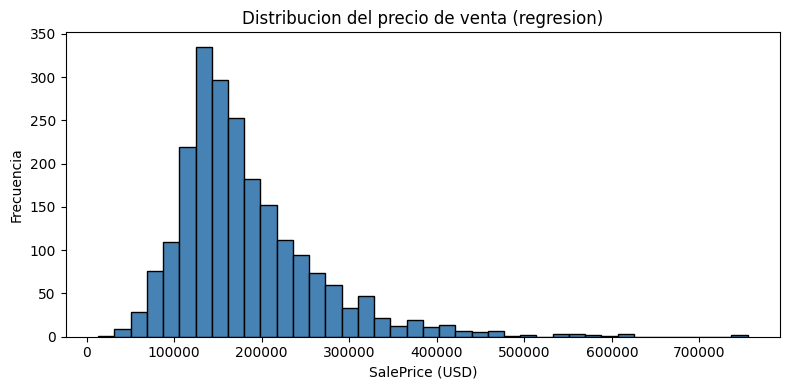

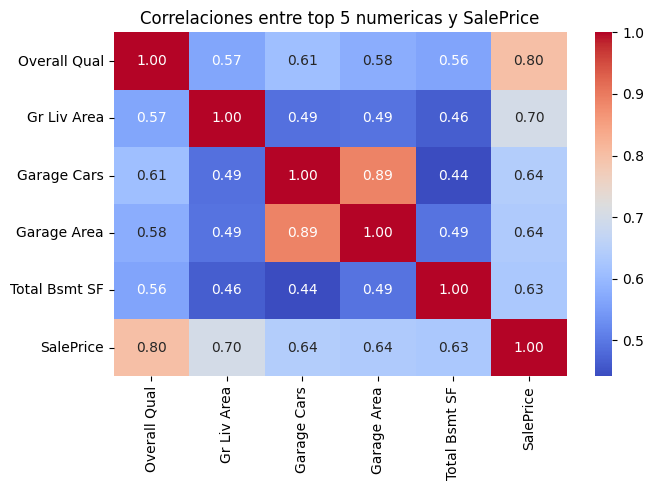

In [3]:
y = df_clean["SalePrice"].astype(float)  # Objetivo: precio de venta
X = df_clean.drop(columns=["SalePrice"])  # Features: todo excepto el precio

print("X.shape =", X.shape)  # Filas y columnas de features
print("y.shape =", y.shape)  # Longitud del vector objetivo

# Correlacion solo con columnas numericas en X
num_x = X.select_dtypes(include=[np.number]).columns  # Subconjunto numerico
corr_with_price = X[num_x].corrwith(y).abs().sort_values(ascending=False)  # |corr| con y
print("Top 5 features mas correlacionadas (en valor absoluto) con SalePrice:")  # Titulo
print(corr_with_price.head(5))  # Cinco mayores correlaciones

plt.figure(figsize=(8, 4))  # Tamanio de figura
plt.hist(y, bins=40, color="steelblue", edgecolor="black")  # Histograma de precios
plt.xlabel("SalePrice (USD)")  # Etiqueta eje X
plt.ylabel("Frecuencia")  # Etiqueta eje Y
plt.title("Distribucion del precio de venta (regresion)")  # Titulo del grafico
plt.tight_layout()  # Ajustar margenes
plt.show()  # Mostrar grafico

# Mapa de calor pequeno: top numericas + precio
top5 = corr_with_price.head(5).index.tolist()  # Nombres de las 5 variables
heat_df = df_clean[top5 + ["SalePrice"]].corr()  # Matriz de correlacion
plt.figure(figsize=(7, 5))  # Tamanio
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="coolwarm")  # Heatmap
plt.title("Correlaciones entre top 5 numericas y SalePrice")  # Titulo
plt.tight_layout()  # Ajuste
plt.show()  # Mostrar


## SECCIÓN 3 — ENCODING

- **Nominales** (sin orden intrínseco): barrio (`Neighborhood`), tipo de zona (`MS Zoning`), etc. → **one-hot** (`pd.get_dummies`) para no inventar orden.
- **Ordinales** (escala de calidad): p. ej. `Exter Qual`, `Kitchen Qual`, `Bsmt Qual` (típicamente Ex > Gd > TA > Fa > Po) → **LabelEncoder** con orden fijo cuando es posible.

Listamos columnas categóricas (no numéricas) y aplicamos la estrategia indicada.

In [4]:
X_enc = X.copy()  # Copia para codificar

# Detectar columnas no numericas (object o string en pandas 2+)
non_num = [c for c in X_enc.columns if not pd.api.types.is_numeric_dtype(X_enc[c])]  # Lista categoricas

# Lista nominal vs ordinal por nombre (heuristica documentada)
ordinal_keywords = ("Qual", "QC", "Cond", "Qu")  # Subcadenas que sugieren escala ordinal
ordinal_cols = []  # Lista de ordinales detectadas
nominal_cols = []  # Lista de nominales

for col in non_num:  # Clasificar cada columna categorica
    if any(k in col for k in ordinal_keywords):  # Si el nombre sugiere calidad/condicion
        ordinal_cols.append(col)  # Tratar como ordinal
    else:
        nominal_cols.append(col)  # Tratar como nominal

print("Columnas ordinales (LabelEncoder):", ordinal_cols)  # Mostrar lista
print("Columnas nominales (one-hot):", nominal_cols)  # Mostrar lista

# Label encoding para ordinales: mapear orden Ex>Gd>TA>Fa>Po si aparecen
orden_qual = ["Ex", "Gd", "TA", "Fa", "Po", "NA", "None", ""]  # Orden de mejor a peor aproximado

for col in ordinal_cols:  # Codificar cada ordinal
    le = LabelEncoder()  # Codificador de etiquetas
    # Convertir a string y reemplazar vacios
    s = X_enc[col].astype(str).replace("nan", np.nan).fillna("NA")  # Texto limpio
    # Si los valores son subconjunto de niveles conocidos, usar factorize por orden
    uniq = sorted(s.unique().tolist())  # Valores unicos
    try:
        X_enc[col] = le.fit_transform(s)  # Etiquetas 0..k-1
    except Exception:
        X_enc[col] = pd.Categorical(s).codes  # Respaldo: codigos de categoria

# One-hot para nominales
X_enc = pd.get_dummies(X_enc, columns=nominal_cols, drop_first=False)  # k dummies por nominal

print("Columnas ANTES encoding (aprox):", list(X.columns)[:15], "...")  # Muestra previa
print("Columnas DESPUES encoding:", X_enc.shape[1])  # Numero total de columnas nuevas
display(X_enc.head(5))  # Primeras 5 filas codificadas


Columnas ordinales (LabelEncoder): ['Condition 1', 'Condition 2', 'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual', 'Garage Qual', 'Garage Cond', 'Sale Condition']
Columnas nominales (one-hot): ['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Foundation', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Sale Type']
Columnas ANTES encoding (aprox): ['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style'] ...
Columnas DESPUES encoding: 228


,MS SubClass,Lot Frontage,Lot Area,Condition 1,Condition 2,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_COD,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,20,80.0,9605,2,2,7,6,2007,2007,0.0,...,False,False,False,False,False,False,False,False,False,True
1,20,90.0,14684,2,2,7,7,1990,1991,234.0,...,False,False,False,False,False,False,False,False,False,True
2,20,69.0,14375,2,2,6,6,1958,1958,541.0,...,True,False,False,False,False,False,False,False,False,False
3,120,48.0,6472,2,2,9,5,2008,2008,500.0,...,False,False,False,False,False,False,False,False,False,True
4,80,61.0,9734,6,2,7,5,2004,2004,0.0,...,False,False,False,False,False,False,False,False,False,True


## SECCIÓN 4 — NORMALIZACIÓN

**StandardScaler**: transforma cada columna a media **0** y varianza **1** usando \(z = (x - \mu) / \sigma\) **calculados en el conjunto que se usa para fit** (aquí, todo el dataset antes del split; en producción se recomienda fit solo en train).

**Por qué importa en redes neuronales**: las unidades reciben inputs en escalas similares, evitando que unas dimensiones dominen el entrenamiento (gradientes más estables).

Mostramos **5 filas** antes y después en un subconjunto de columnas numéricas.

In [5]:
# Guardar copia antes de escalar (para comparacion)
antes = X_enc.iloc[:5].copy()  # Cinco primeras filas antes del escalado

scaler = StandardScaler()  # Instancia de escalado estandar
X_scaled = scaler.fit_transform(X_enc)  # Matriz numpy normalizada
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # Volver a DataFrame

despues = X_scaled_df.iloc[:5].copy()  # Cinco filas despues

print("=== Comparativa 5 filas: ANTES (izquierda) vs DESPUES (derecha) [primeras 8 columnas] ===")  # Titulo
cols_show = list(X_enc.columns[:8])  # Subconjunto de columnas para legibilidad
comp = pd.concat([antes[cols_show], despues[cols_show]], axis=1, keys=["ANTES", "DESPUES"])  # Tabla unida
display(comp)  # Mostrar comparativa


=== Comparativa 5 filas: ANTES (izquierda) vs DESPUES (derecha) [primeras 8 columnas] ===


ANTES                                                             \
  MS SubClass Lot Frontage Lot Area Condition 1 Condition 2 Overall Qual   
0          20         80.0     9605           2           2            7   
1          20         90.0    14684           2           2            7   
2          20         69.0    14375           2           2            6   
3         120         48.0     6472           2           2            9   
4          80         61.0     9734           6           2            7   

                              DESPUES                                     \
  Overall Cond Year Built MS SubClass Lot Frontage  Lot Area Condition 1   
0            6       2007   -0.875166     0.497528 -0.083155   -0.052122   
1            7       1990   -0.875166     0.969513  0.553796   -0.052122   
2            6       1958   -0.875166    -0.021655  0.515045   -0.052122   
3            5       2008    1.486051    -1.012823 -0.476060   -0.052122   
4            5       2004    0.541564    -0.399243 -0.066977    4.528342   

                                                    
  Condition 2 Overall Qual Overall Cond Year Built  
0   -0.026334     0.618124     0.404266   1.148668  
1   -0.026334     0.618124     1.307799   0.590250  
2   -0.026334    -0.081525     0.404266  -0.460890  
3   -0.026334     2.017423    -0.499267   1.181516  
4   -0.026334     0.618124    -0.499267   1.050123

## SECCIÓN 5 — TRAIN / TEST SPLIT

- **80% entrenamiento / 20% prueba**, `random_state=42` para **reproducibilidad**.
- **Train**: ajuste del modelo; **test**: estimación honesta del error fuera de muestra.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(  # Particion estratificada no aplica a regresion continua
    X_scaled_df,  # Features ya escaladas
    y,  # Objetivo
    test_size=0.2,  # 20% para test
    random_state=42,  # Semilla fija
)

print("X_train.shape =", X_train.shape)  # Tamano train
print("X_test.shape =", X_test.shape)  # Tamano test
print("y_train.shape =", y_train.shape)  # Tamano y train
print("y_test.shape =", y_test.shape)  # Tamano y test


X_train.shape = (1757, 228)
X_test.shape = (440, 228)
y_train.shape = (1757,)
y_test.shape = (440,)


## SECCIÓN 6 — MODELO DE PRUEBA (baseline)

**LinearRegression** como comprobación de que el pipeline funciona. Métricas:
- **MSE**: error cuadrático medio (penaliza grandes errores).
- **R²**: fracción de varianza explicada (1 es perfecto, 0 similar a predecir la media).

No es el modelo final; sirve de **sanity check**.

In [7]:
modelo = LinearRegression()  # Regresion lineal ordinaria
modelo.fit(X_train, y_train)  # Entrenar con train
pred = modelo.predict(X_test)  # Predecir en test

mse = mean_squared_error(y_test, pred)  # Error cuadratico medio
r2 = r2_score(y_test, pred)  # Coeficiente de determinacion

print("MSE en test:", round(mse, 2))  # Imprimir MSE
print("R2 en test:", round(r2, 4))  # Imprimir R2
print("Interpretacion: R2 cercano a 1 indica buen ajuste; MSE en unidades USD^2.")  # Explicacion breve


MSE en test: 971851747.99
R2 en test: 0.8165
Interpretacion: R2 cercano a 1 indica buen ajuste; MSE en unidades USD^2.


## SECCIÓN 7 — GUARDADO DE ARCHIVOS

Se guardan el CSV limpio (sin escalar, con `SalePrice` para referencia) y los cuatro CSV de split **con features escaladas** para entrenamiento directo.

In [8]:
out_dir = ROOT_NB / "1. Ames Housing Dataset"  # Carpeta del dataset
out_dir.mkdir(parents=True, exist_ok=True)  # Crear si no existe

# Tabla final lista para modelado: features escaladas + objetivo
df_final_ml = pd.concat([X_scaled_df, y.rename("SalePrice")], axis=1)  # Unir X normalizado y precio
fname_clean = out_dir / "ames_housing_clean.csv"  # Archivo de dataset limpio final
df_final_ml.to_csv(fname_clean, index=False)  # Guardar matriz final
print("Guardado:", fname_clean)  # Confirmacion

X_train.to_csv(out_dir / "X_train.csv", index=False)  # Train features escaladas
X_test.to_csv(out_dir / "X_test.csv", index=False)  # Test features escaladas
y_train.to_csv(out_dir / "y_train.csv", index=True, header=True)  # Train objetivo
y_test.to_csv(out_dir / "y_test.csv", index=True, header=True)  # Test objetivo
print("Guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv")  # Confirmacion


Guardado: C:\Users\Hp\OneDrive\Escritorio\primerparcial_ia\1. Ames Housing Dataset\ames_housing_clean.csv
Guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv


## SECCIÓN 8 — RESUMEN FINAL

Comprobaciones finales y caja de resumen.

In [9]:
display(df_clean.head(10))  # Diez primeras filas del dataframe saneado (con SalePrice)

print("Shape final df_clean:", df_clean.shape)  # Dimensiones
print("Columnas finales (lista):", list(df_clean.columns))  # Nombres

assert df_clean.isnull().sum().sum() == 0, "Hay nulos"  # Sin nulos
# Tras encoding en X_scaled_df todo es numerico
assert np.all(np.isfinite(X_scaled_df.values)), "Hay no finitos"  # Sin inf/NaN en X escalado

print("+------------- RESUMEN -------------+")  # Caja resumen
print("| Dataset: Ames Housing (Iowa)")  # Nombre
print("| Objetivo: precio SalePrice (USD)")  # Target
print("| Filas/columnas finales (saneado):", df_clean.shape)  # Shape
print("| Numero de features en X tras encoding:", X_enc.shape[1])  # Features
print("| Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])  # Particion
print("| Baseline R2 (test):", round(r2, 4))  # Metrica
print("+-----------------------------------+")  # Cierre


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,80.0,9605,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2009,WD,Normal,159000
1,20,RL,90.0,14684,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,0,6,2009,WD,Normal,271900
2,20,RL,69.0,14375,Pave,IR1,Lvl,NoSeWa,CulDSac,Gtl,...,0,0,233,0,0,1,2009,COD,Abnorml,137500
3,120,RL,48.0,6472,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,4,2009,WD,Normal,248500
4,80,RL,61.0,9734,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,5,2009,WD,Normal,167000
5,20,RL,70.0,7315,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,225,0,0,3,2007,WD,Normal,140000
6,20,RL,71.0,7350,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2009,WD,Normal,128000
7,60,RL,69.0,11050,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,213000
8,20,RL,65.0,7150,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2009,WD,Normal,100000
9,60,RL,69.0,18800,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,7,2006,WD,Normal,190000


Shape final df_clean: (2197, 74)
Columnas finales (lista): ['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Dec